# DATA 266 Homework 3

## Prompt Engineering and Self Attention from Scratch

**SID4:** 2046  
**SEED:** 2046  
**SLICE:** 46  
**HP_ID:** 0  
**CLS_A:** 6  
**CLS_B:** 3  



In [ ]:
import os
import sys
import math
import random
import subprocess
import importlib.util
from pathlib import Path

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

ensure_package("langchain_google_genai", "langchain-google-genai")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import torch
import torch.nn as nn
import torch.nn.functional as F

SID4 = 2046
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path("figures").mkdir(exist_ok=True)

print("SID4 =", SID4)
print("SEED =", SEED)
print("SLICE =", SLICE)
print("HP_ID =", HP_ID)
print("CLS_A =", CLS_A)
print("CLS_B =", CLS_B)
print("Device =", device)

SID4 = 2046
SEED = 2046
SLICE = 46
HP_ID = 0
CLS_A = 6
CLS_B = 3
Device = cuda


# Part 1: Prompt Engineering

I used the same two tasks for all six prompting techniques so the comparison stays fair. Task A is a small mathematical reasoning problem. Task B asks the model to interpret mixed evidence in a customer review.

Using the same tasks makes it easier to see what changed because of the prompt instead of because one question happened to be harder than another.

The Gemini API key is requested securely at runtime and is not written into the notebook.


In [ ]:
import os
import time
import re
import getpass
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import display, Markdown

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Gemini API key: ")

llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

def extract_text(content):
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for part in content:
            if isinstance(part, dict) and part.get("type") == "text":
                parts.append(part.get("text", ""))
            else:
                parts.append(str(part))
        return "\n".join(parts)
    return str(content)

def call_llm(prompt, max_retries=6):
    for attempt in range(max_retries):
        try:
            response = llm.invoke(prompt)
            return extract_text(response.content)
        except Exception as e:
            error_text = str(e)
            if "429" in error_text or "RESOURCE_EXHAUSTED" in error_text:
                match = re.search(r"retryDelay[^0-9]*(\d+)s", error_text)
                wait_time = int(match.group(1)) + 5 if match else 65
                print(f"Rate limit reached. Waiting {wait_time} seconds before retrying.")
                time.sleep(wait_time)
            else:
                raise
    raise RuntimeError("Gemini request failed after repeated rate limit retries.")

TASK_A = """A farmer has chickens and cows. There are 35 heads and 94 legs.
How many chickens and cows are there?"""

TASK_B = """A customer writes:
"The headphones sound great, but they stopped charging after two days.
Customer support replaced them immediately and the replacement works perfectly."

Classify the overall sentiment as positive, negative, or mixed and briefly justify the classification."""

results = []
print("Gemini initialized successfully.")


Enter your Gemini API key: ··········
Gemini initialized successfully.


## 1. Zero Shot

For zero shot prompting, I gave Gemini the task directly without examples or a special reasoning structure. This gives me a baseline for how the model responds with minimal guidance.


In [ ]:
prompts = [
    ("A", f"Solve the following problem and give the final answer.\n\n{TASK_A}"),
    ("B", f"Complete the following classification task.\n\n{TASK_B}")
]
for example, prompt in prompts:
    output = call_llm(prompt)
    results.append({"Technique":"Zero Shot","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

To find the number of chickens and cows, we can set up a system of equations based on the number of heads and legs.

Let:
* $c$ = number of chickens (each has 1 head and 2 legs)
* $w$ = number of cows (each has 1 head and 4 legs)

**Step 1: Write the equations**
1. Heads equation: $c + w = 35$
2. Legs equation: $2c + 4w = 94$

**Step 2: Solve the system of equations**
From the first equation, express $c$ in terms of $w$:
$$c = 35 - w$$

Substitute $c$ into the second equation:
$$2(35 - w) + 4w = 94$$
$$70 - 2w + 4w = 94$$
$$70 + 2w = 94$$
$$2w = 24$$
$$w = 12$$

**Step 3: Find the number of chickens**
$$c = 35 - 12 = 23$$

**Conclusion:**
There are **23 chickens** and **12 cows**.

### Example B

**Classification:** Mixed

**Justification:** 
The review contains both negative and positive elements. The negative aspect is the product defect (the headphones stopped charging after two days), while the positive aspects include the initial sound quality, the quick response from customer support, and the fact that the replacement product works perfectly.

## 2. Few Shot

For few shot prompting, I included two short demonstrations before each target problem. The demonstrations show the expected answer pattern without giving away the answer to the new problem.


In [ ]:
few_a = f"""Solve each animal counting problem.

Example:
There are 10 animals consisting of chickens and cows and 28 legs total.
Answer: 6 chickens and 4 cows.

Example:
There are 8 animals consisting of chickens and cows and 22 legs total.
Answer: 5 chickens and 3 cows.

Now solve:
{TASK_A}"""

few_b = f"""Classify sentiment as positive, negative, or mixed.

Example:
"The camera is excellent, but delivery was three weeks late."
Answer: Mixed

Example:
"The setup was easy and the software has worked perfectly."
Answer: Positive

Now classify:
{TASK_B}"""

for example, prompt in [("A", few_a), ("B", few_b)]:
    output = call_llm(prompt)
    results.append({"Technique":"Few Shot","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

Answer: 23 chickens and 12 cows.

### Example B

**Answer:** Mixed

**Justification:** The text contains both positive and negative elements. The customer experienced a major issue with the product (it stopped charging after two days), but also highlighted positive aspects (great sound quality, fast customer support, and a working replacement).

## 3. Chain of Thought

Here I explicitly asked the model to work through intermediate reasoning before giving its final answer. For the math task, it checks the constraints. For the sentiment task, it separates positive and negative evidence before deciding.


In [ ]:
prompts = [
    ("A", f"""Solve this problem using a concise sequence of intermediate calculations. Check the result against both constraints before giving the final answer.

{TASK_A}"""),
    ("B", f"""Analyze the positive evidence and negative evidence separately. Then combine those observations to determine the overall sentiment and finish with one final classification.

{TASK_B}""")
]
for example, prompt in prompts:
    output = call_llm(prompt)
    results.append({"Technique":"Chain of Thought","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

**Calculations:**
1. Assume all 35 animals are chickens (2 legs each): $35 \times 2 = 70 \text{ legs}$
2. Difference between actual legs and assumed legs: $94 - 70 = 24 \text{ legs}$
3. Difference in legs per cow compared to a chicken: $4 - 2 = 2 \text{ legs}$
4. Number of cows: $24 \div 2 = 12$
5. Number of chickens: $35 - 12 = 23$

---

**Constraint Checks:**
1. **Heads constraint:** $23 \text{ chickens} + 12 \text{ cows} = 35 \text{ heads}$ (Correct)
2. **Legs constraint:** $(23 \times 2) + (12 \times 4) = 46 + 48 = 94 \text{ legs}$ (Correct)

---

**Final Answer:**
There are **23 chickens** and **12 cows**.

### Example B

### Positive Evidence
* **Product Quality:** The customer notes that the headphones "sound great" and that the replacement "works perfectly."
* **Customer Service:** The customer highlights that support "replaced them immediately," showing high satisfaction with the prompt and effective service recovery.

### Negative Evidence
* **Product Defect:** The original pair "stopped charging after two days," indicating a reliability/hardware issue shortly after purchase.

### Combined Observations
Although the customer experienced an initial product failure, the negative experience was swiftly and fully resolved by excellent customer support. The review ends on a strong, satisfied note regarding both the product's performance and the company's service. The successful resolution outweighs the temporary defect, leaving the customer overall very satisfied.

### Final Classification
**Positive**
**Justification:** While an initial defect occurred, the swift support response and fully functional replacement resolved the issue completely, resulting in an overall highly satisfied customer experience.

## 4. Zero Shot Chain of Thought

This version still gives the model no demonstrations. The only addition is a general instruction to think through the problem step by step before answering. This lets me compare a simple reasoning cue with the more structured Chain of Thought prompt above.


In [ ]:
prompts = [
    ("A", f"{TASK_A}\n\nThink through the problem step by step, verify the result, and then state the final answer."),
    ("B", f"{TASK_B}\n\nThink through the evidence step by step before stating the final classification.")
]
for example, prompt in prompts:
    output = call_llm(prompt)
    results.append({"Technique":"Zero Shot CoT","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

Here is the step-by-step solution to the problem:

### **Step 1: Identify the given information and set up equations**
* A chicken has **1 head** and **2 legs**.
* A cow has **1 head** and **4 legs**.
* Total heads = 35 (which means the total number of animals is 35).
* Total legs = 94.

Let:
* $C$ = number of chickens
* $W$ = number of cows

We can write two equations based on heads and legs:
1. **Heads equation:** $C + W = 35$
2. **Legs equation:** $2C + 4W = 94$

---

### **Step 2: Solve the system of equations**

From the heads equation, we can express $C$ in terms of $W$:
$$C = 35 - W$$

Substitute $C$ into the legs equation:
$$2(35 - W) + 4W = 94$$
$$70 - 2W + 4W = 94$$
$$70 + 2W = 94$$

Subtract 70 from both sides:
$$2W = 94 - 70$$
$$2W = 24$$
$$W = 12$$

So, there are **12 cows**.

Now, find the number of chickens ($C$):
$$C = 35 - 12$$
$$C = 23$$

So, there are **23 chickens**.

---

### **Step 3: Verify the result**

* **Check total heads:**
  $$23 \text{ chickens} + 12 \text{ cows} = 35 \text{ heads} \quad \checkmark$$

* **Check total legs:**
  $$(23 \times 2 \text{ legs}) + (12 \times 4 \text{ legs}) = 46 + 48 = 94 \text{ legs} \quad \checkmark$$

---

### **Final Answer:**
There are **23 chickens** and **12 cows**.

### Example B

**Step-by-Step Analysis of the Evidence:**

1. **"The headphones sound great..."** 
   * *Sentiment:* **Positive** (praises the audio quality of the product).

2. **"...but they stopped charging after two days."** 
   * *Sentiment:* **Negative** (highlights a major product failure/defect).

3. **"Customer support replaced them immediately..."** 
   * *Sentiment:* **Positive** (commends the speed and helpfulness of customer service).

4. **"...and the replacement works perfectly."** 
   * *Sentiment:* **Positive** (expresses satisfaction with the final product and resolution).

**Synthesis:**
The customer expresses significant initial disappointment due to a product defect (a negative aspect), but balances this with praise for the sound quality, prompt customer service, and a fully functional replacement (positive aspects). Because the statement contains both a clear negative event and strong positive outcomes/feedback, it represents a combination of conflicting sentiments.

**Final Classification:** **Mixed**

## 5. Meta Prompting

For meta prompting, I asked the model to first describe a general method for solving the type of problem and only then apply that method to the specific example. The goal is to see whether the model separates reusable strategy from the final answer.


In [ ]:
prompts = [
    ("A", f"""First identify a general method for solving two category counting problems when the total number of items and a second weighted total are known. Then apply that method to the problem below. Keep the general method separate from the final calculation.

{TASK_A}"""),
    ("B", f"""First define a general decision procedure for classifying a review as positive, negative, or mixed when it contains both product and service experiences. Then apply that procedure to the review below.

{TASK_B}""")
]
for example, prompt in prompts:
    output = call_llm(prompt)
    results.append({"Technique":"Meta Prompting","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

### Part 1: General Method

This type of problem can be modeled as a system of two linear equations with two unknowns. 

#### **Variables:**
* $N$ = Total number of items
* $W$ = Total weighted value
* $x$ = Number of Category A items
* $y$ = Number of Category B items
* $w_x$ = Weight per item in Category A
* $w_y$ = Weight per item in Category B (assume $w_y > w_x$)

---

#### **System of Equations:**
1. **Item Count Equation:**  
   $$x + y = N$$

2. **Weighted Total Equation:**  
   $$(w_x \cdot x) + (w_y \cdot y) = W$$

---

#### **Step-by-Step Solution Procedure:**

1. **Assume the minimum baseline:**  
   Calculate what the total weighted value would be if *all* items belonged to the category with the lower weight ($Category\ A$).  
   $$\text{Baseline Weight} = N \cdot w_x$$

2. **Find the total weight difference (excess weight):**  
   Subtract the baseline weight from the actual total weight $W$.  
   $$\Delta W = W - (N \cdot w_x)$$

3. **Find the unit weight difference:**  
   Subtract the smaller weight per item from the larger weight per item.  
   $$\Delta w = w_y - w_x$$

4. **Calculate the quantity of the higher-weighted items ($y$):**  
   Divide the excess weight by the unit weight difference.  
   $$y = \frac{\Delta W}{\Delta w} = \frac{W - (N \cdot w_x)}{w_y - w_x}$$

5. **Calculate the quantity of the lower-weighted items ($x$):**  
   Subtract $y$ from the total number of items.  
   $$x = N - y$$

---

### Part 2: Application to the Problem

#### **Given Data:**
* Total heads ($N$) = $35$
* Total legs ($W$) = $94$
* Chickens ($x$): $w_x = 2$ legs each
* Cows ($y$): $w_y = 4$ legs each

---

#### **Calculations:**

1. **Calculate the baseline legs (if all 35 items were chickens):**  
   $$\text{Baseline Weight} = 35 \text{ heads} \times 2 \text{ legs/chicken} = 70 \text{ legs}$$

2. **Find the excess legs:**  
   $$\Delta W = 94 - 70 = 24 \text{ legs}$$

3. **Find the difference in legs per animal:**  
   $$\Delta w = 4 \text{ legs/cow} - 2 \text{ legs/chicken} = 2 \text{ legs}$$

4. **Calculate the number of cows ($y$):**  
   $$y = \frac{24}{2} = 12 \text{ cows}$$

5. **Calculate the number of chickens ($x$):**  
   $$x = 35 - 12 = 23 \text{ chickens}$$

---

#### **Final Answer:**
There are **23 chickens** and **12 cows**. 

*(Verification: $23 + 12 = 35$ heads; $(23 \times 2) + (12 \times 4) = 46 + 48 = 94$ legs.)*

### Example B

### **General Decision Procedure for Multi-Aspect Sentiment Classification**

To classify a review containing both product and service experiences into **Positive**, **Negative**, or **Mixed**, follow this 4-step procedure:

1. **Aspect Segmentation:** Break the review down into discrete statements categorized by target:
   * **Product Aspects:** Performance, features, build quality, defects.
   * **Service Aspects:** Customer support, shipping, responsiveness, resolution efforts.

2. **Polarity Assignment:** Assign a polarity—Positive (+), Negative (-), or Neutral (0)—to each identified segment.

3. **Resolution Arc Evaluation:** Check if a negative aspect was resolved by a positive one (or vice versa):
   * *Fully Resolved Arc:* A negative product/service issue is completely remediated by an excellent service/product response, leaving the user fully satisfied.
   * *Unresolved/Ongoing Arc:* A negative issue persists despite service efforts, or service was poor regardless of product quality.

4. **Overall Classification Rules:**
   * **Positive:** 
     * All aspects are positive, **OR**
     * An initial negative issue was promptly and completely resolved by customer service, leaving a fully functional product and zero lingering customer dissatisfaction.
   * **Negative:** 
     * The primary experience ends in failure, severe inconvenience, or unresolved defects, **OR**
     * Negative aspects significantly outweigh minor positive mentions.
   * **Mixed:** 
     * Both positive and negative aspects coexist without resolution (e.g., "Great sound, but customer service refused to help"), **OR**
     * The resolution was partial, delayed, or inconvenient enough that the customer remains conflicted.

---

### **Application to the Review**

**Review:**  
*"The headphones sound great, but they stopped charging after two days. Customer support replaced them immediately and the replacement works perfectly."*

#### **Step-by-Step Application:**
1. **Aspect Segmentation:**
   * *Product (Initial Performance):* "sound great"
   * *Product (Initial Defect):* "stopped charging after two days"
   * *Service (Support Response):* "replaced them immediately"
   * *Product (Final State):* "replacement works perfectly"

2. **Polarity Assignment:**
   * Sound Quality: **Positive (+)**
   * Defect: **Negative (-)**
   * Customer Support: **Positive (+)**
   * Replacement Unit: **Positive (+)**

3. **Resolution Arc Evaluation:**
   * The initial product failure (charging issue) was met with immediate service action, resulting in a replacement that works perfectly. The arc moves from a temporary negative to a complete, positive resolution.

4. **Classification Determination:**
   * Matches the **Positive** rule for a fully resolved issue with a successful final outcome and excellent service.

---

### **Final Classification & Justification**

* **Overall Classification:** **Positive**
* **Justification:** While the review mentions a product defect, the issue was immediately and completely resolved by customer support. Because the customer highlights both prompt service and complete satisfaction with the final product ("works perfectly"), the resolution arc closes positively with no remaining frustration expressed.

## 6. Tree of Thoughts

For Tree of Thoughts, I asked the model to consider several possible approaches or interpretations before choosing one. The math prompt compares three solution strategies, while the sentiment prompt compares positive, negative, and mixed interpretations.


In [ ]:
prompts = [
    ("A", f"""Consider three possible ways to solve this problem: algebraic equations, substitution using the head count, and systematic counting. Evaluate which approach is most reliable and efficient. Use the selected approach, verify the answer, and give the final result.

{TASK_A}"""),
    ("B", f"""Consider three interpretations of this review: positive, negative, and mixed. For each interpretation, identify evidence that supports or weakens it. Select the interpretation best supported by the complete review and give the final classification.

{TASK_B}""")
]
for example, prompt in prompts:
    output = call_llm(prompt)
    results.append({"Technique":"Tree of Thoughts","Example":example,"Prompt":prompt,"Output":output})
    display(Markdown(f"### Example {example}\n\n{output}"))
    time.sleep(5)


### Example A

### 1. Evaluation of the Three Approaches

*   **Approach 1: Algebraic Equations**
    *   **Reliability:** **Extremely High.** It relies on strict mathematical rules, leaving no room for human counting errors or missed cases. It works regardless of how large the numbers are.
    *   **Efficiency:** **High.** It requires setting up a system of two linear equations and solving them in just a few quick steps.
*   **Approach 2: Substitution using Head Count (Logical Deduction)**
    *   **Reliability:** **High.** It uses logical reasoning (e.g., assuming all animals are chickens and distributing the leftover legs). 
    *   **Efficiency:** **Very High.** It is often the fastest method for mental math with small numbers, but can be slightly more difficult to explain formally or apply to complex multi-variable problems.
*   **Approach 3: Systematic Counting (Trial and Error / Listing)**
    *   **Reliability:** **Moderate to Low.** While it will eventually lead to the correct answer, manually testing combinations increases the risk of basic calculation or transcription errors.
    *   **Efficiency:** **Very Low.** It requires checking up to 35 different combinations step-by-step, making it time-consuming.

**Selection:** **Algebraic Equations** is selected as the most reliable and efficient method overall. It provides a formal, error-proof framework that directly yields the answer without reliance on guessing or tedious step-by-step counting.

---

### 2. Solution Using the Selected Approach (Algebraic Equations)

Let:
*   $c =$ number of chickens
*   $w =$ number of cows

**Step 1: Set up the system of equations based on the problem constraints.**
1.  **Head count equation:** Each animal has 1 head.
    $$c + w = 35$$
2.  **Leg count equation:** Chickens have 2 legs; cows have 4 legs.
    $$2c + 4w = 94$$

**Step 2: Solve the system using substitution or elimination.**
From the first equation, express $c$ in terms of $w$:
$$c = 35 - w$$

Substitute this expression into the second equation:
$$2(35 - w) + 4w = 94$$
$$70 - 2w + 4w = 94$$
$$70 + 2w = 94$$

Subtract 70 from both sides:
$$2w = 24$$
$$w = 12$$

**Step 3: Find the number of chickens ($c$).**
$$c = 35 - 12$$
$$c = 23$$

---

### 3. Verification

*   **Verify Heads:** 
    $$23 \text{ chickens} + 12 \text{ cows} = 35 \text{ heads} \quad \checkmark$$
*   **Verify Legs:** 
    $$(23 \times 2 \text{ legs}) + (12 \times 4 \text{ legs}) = 46 + 48 = 94 \text{ legs} \quad \checkmark$$

Both conditions are fully satisfied.

---

### 4. Final Result

There are **23 chickens** and **12 cows**.

### Example B

Here is the evaluation of the three interpretations based on the review:

### 1. Positive Interpretation
* **Supporting Evidence:** The reviewer states the headphones "sound great," praises customer service for replacing them "immediately," and notes that the replacement "works perfectly." The final resolution completely satisfied the customer.
* **Weakening Evidence:** The original product failed almost immediately ("stopped charging after two days"), which represents a significant quality flaw.

---

### 2. Negative Interpretation
* **Supporting Evidence:** The product suffered a major hardware defect within just two days of use ("stopped charging"), indicating poor initial quality control.
* **Weakening Evidence:** The reviewer explicitly commends the sound quality, the rapid responsiveness of support, and the flawless performance of the replacement unit.

---

### 3. Mixed Interpretation
* **Supporting Evidence:** The review contains a clear contrast between a major negative event (product breaking after two days) and several positive events (great initial sound, excellent customer service, and a working replacement).
* **Weakening Evidence:** The negative issue was fully resolved, leaving the customer with no ongoing complaints or unresolved frustration. 

---

### Best-Supported Interpretation & Final Classification

**Final Classification:** **Positive**

**Justification:** 
While the review contains a brief negative point regarding a product failure, the overwhelming focus is on the positive aspects: great sound quality, outstanding customer service, and a fully functional replacement. Because the problem was resolved swiftly and completely, the overall trajectory of the customer's experience and sentiment ends on a highly satisfied note.

## Prompt Engineering Comparison

The table below collects all twelve programmatic responses. I also compare output length because it gives a simple quantitative view of how much additional reasoning each prompting method produced.


In [ ]:
prompt_results = pd.DataFrame(results)
prompt_results[["Technique", "Example", "Output"]]

,Technique,Example,Output
0,Zero Shot,A,"To find the number of chickens and cows, we ca..."
1,Zero Shot,B,**Classification:** Mixed\n\n**Justification:*...
2,Few Shot,A,Answer: 23 chickens and 12 cows.
3,Few Shot,B,**Answer:** Mixed\n\n**Justification:** The te...
4,Chain of Thought,A,**Calculations:**\n1. Assume all 35 animals ar...
5,Chain of Thought,B,### Positive Evidence\n* **Product Quality:** ...
6,Zero Shot CoT,A,Here is the step-by-step solution to the probl...
7,Zero Shot CoT,B,**Step-by-Step Analysis of the Evidence:**\n\n...
8,Meta Prompting,A,### Part 1: General Method\n\nThis type of pro...
9,Meta Prompting,B,### **General Decision Procedure for Multi-Asp...


In [ ]:
prompt_results.to_csv("prompt_engineering_results.csv", index=False)

summary = []
for technique in prompt_results["Technique"].unique():
    subset = prompt_results[prompt_results["Technique"] == technique]
    word_counts = subset["Output"].astype(str).str.split().str.len()
    summary.append({
        "Technique": technique,
        "Examples": len(subset),
        "Average output words": round(float(word_counts.mean()), 1)
    })

prompt_summary = pd.DataFrame(summary)
prompt_summary

,Technique,Examples,Average output words
0,Zero Shot,2,98.0
1,Few Shot,2,23.5
2,Chain of Thought,2,130.0
3,Zero Shot CoT,2,187.0
4,Meta Prompting,2,413.5
5,Tree of Thoughts,2,325.0


### Prompt Engineering Findings

All six prompting techniques produced the same answer for Task A: **23 chickens and 12 cows**. This shows that the mathematical problem was fairly stable across the different prompt styles. The main difference I noticed was in how much explanation each technique produced rather than whether it reached the correct answer.

The average output lengths were **98.0 words for Zero Shot**, **23.5 words for Few Shot**, **130.0 words for Chain of Thought**, **187.0 words for Zero Shot CoT**, **413.5 words for Meta Prompting**, and **325.0 words for Tree of Thoughts**. Few Shot was the most concise, while Meta Prompting produced the longest responses. In this example, a longer response did not necessarily mean a better answer because all six techniques solved Task A correctly.

Task B showed more sensitivity to the way the prompt was structured. **Zero Shot, Few Shot, Chain of Thought, and Zero Shot CoT classified the review as Mixed**, while **Meta Prompting and Tree of Thoughts classified it as Positive**. This suggests that the more structured prompts gave more importance to the successful replacement and the positive ending of the review, while the other techniques gave more weight to both the negative and positive parts.

Overall, I found that changing the prompting technique affected the amount of reasoning and explanation much more clearly than it affected correctness. For the sentiment example, however, the prompt structure also changed how the model interpreted the same text.



# Part 2: Self Attention and Causal Masking From Scratch

I use the assignment paragraph exactly as provided and tokenize it at the word level. Splitting on whitespace produces 46 token positions and a vocabulary of 40 unique tokens.

I train two separate models with the same basic architecture and training settings. The first uses unmasked self attention. The second applies a causal mask before softmax. Both models learn their embeddings and Q, K, and V projections through a next token prediction objective.

This means the heatmaps are based on learned attention weights, not random initialization.


In [ ]:
TEXT = """Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time."""

tokens = TEXT.split()
vocab = sorted(set(tokens))
token_to_id = {token: i for i, token in enumerate(vocab)}
id_to_token = {i: token for token, i in token_to_id.items()}
token_ids = torch.tensor([token_to_id[token] for token in tokens], dtype=torch.long)

print("Number of tokens:", len(tokens))
print("Vocabulary size:", len(vocab))
print(tokens)

Number of tokens: 46
Vocabulary size: 40
['Neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data.', 'They', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons.', 'Attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input.', 'Transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence.', 'Autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time.']


## Scaled Dot Product Self Attention

Each token is first mapped to a trainable embedding. Three learned linear projections turn those embeddings into queries, keys, and values:

\[
Q=XW_Q,\qquad K=XW_K,\qquad V=XW_V
\]

I calculate the attention scores directly with:

\[
S=\frac{QK^T}{\sqrt{d_k}}
\]

The division by \(\sqrt{d_k}\) keeps dot products from growing too large as the key dimension increases. Without this scaling, softmax can become overly peaked and harder to optimize.

For the unmasked model, I apply softmax directly:

\[
A=\operatorname{softmax}(S)
\]

The attended representation is:

\[
Z=AV
\]

For the causal model, I create a lower triangular Boolean mask. Any score corresponding to a future position is replaced with negative infinity before softmax. Softmax therefore assigns those future positions a probability of zero.


In [ ]:
class ScratchSelfAttentionLanguageModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, d_k=64, causal=False):
        super().__init__()
        self.d_k = d_k
        self.causal = causal

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.q_proj = nn.Linear(d_model, d_k, bias=False)
        self.k_proj = nn.Linear(d_model, d_k, bias=False)
        self.v_proj = nn.Linear(d_model, d_k, bias=False)
        self.output_proj = nn.Linear(d_k, vocab_size)

    def forward(self, input_ids, return_attention=False):
        x = self.embedding(input_ids)

        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(self.d_k)

        if self.causal:
            seq_len = scores.size(-1)
            mask = torch.tril(
                torch.ones(seq_len, seq_len, device=scores.device, dtype=torch.bool)
            )
            scores = scores.masked_fill(~mask, float("-inf"))

        attention_weights = torch.softmax(scores, dim=-1)
        attended_values = torch.matmul(attention_weights, V)
        logits = self.output_proj(attended_values)

        if return_attention:
            return logits, attention_weights
        return logits

## Training Objective

The models are trained with next token prediction. If the sequence is

\[
x_1,x_2,\ldots,x_T
\]

then the input contains positions \(1\) through \(T-1\), while the targets contain positions \(2\) through \(T\). With 46 tokens, this produces **45 next token training pairs**. At each position, the model tries to predict the word that comes next.

I use cross entropy loss and Adam optimization for **500 epochs** with a learning rate of **0.01**. Both models use **SEED = 2046**, an embedding dimension of **64**, and a key, query, and value dimension of **64**. The only intended architectural difference is whether the causal mask is applied.


In [ ]:
def train_model(causal, seed=SEED, epochs=500, learning_rate=0.01):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = ScratchSelfAttentionLanguageModel(
        vocab_size=len(vocab),
        d_model=64,
        d_k=64,
        causal=causal
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    input_ids = token_ids[:-1].to(device)
    targets = token_ids[1:].to(device)
    losses = []

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = model(input_ids)
        loss = F.cross_entropy(
            logits.reshape(-1, len(vocab)),
            targets.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))

        if epoch == 0 or (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} | Loss: {loss.item():.6f}")

    return model, losses

## Unmasked Model

The first model has no causal restriction. A token can assign attention to earlier positions, itself, or later positions. I train it before extracting the attention matrix so the heatmap reflects learned Q, K, V, and embedding parameters.


In [ ]:
unmasked_model, unmasked_losses = train_model(causal=False, seed=SEED)

Epoch   1/500 | Loss: 3.701041
Epoch 100/500 | Loss: 0.227959
Epoch 200/500 | Loss: 0.227603
Epoch 300/500 | Loss: 0.227425
Epoch 400/500 | Loss: 0.227422
Epoch 500/500 | Loss: 0.228414


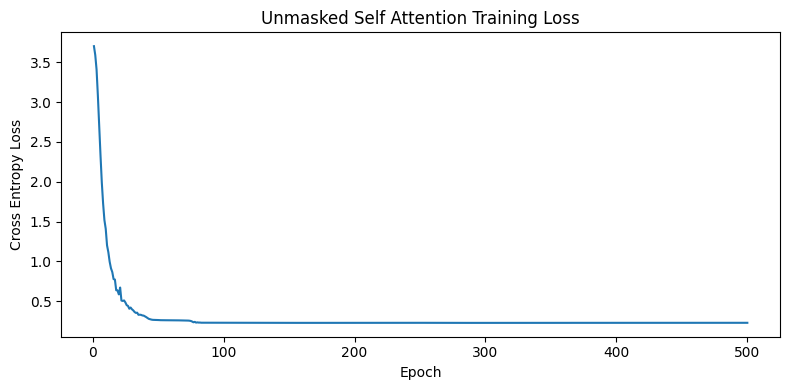

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(unmasked_losses) + 1), unmasked_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Unmasked Self Attention Training Loss")
plt.tight_layout()
plt.savefig("figures/unmasked_training_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
unmasked_model.eval()
full_ids = token_ids.to(device)

with torch.no_grad():
    _, unmasked_attention = unmasked_model(full_ids, return_attention=True)

unmasked_attention_np = unmasked_attention.cpu().numpy()
print("Attention matrix shape:", unmasked_attention_np.shape)
print("Maximum row sum error:", np.abs(unmasked_attention_np.sum(axis=1) - 1.0).max())

Attention matrix shape: (46, 46)
Maximum row sum error: 2.3841858e-07


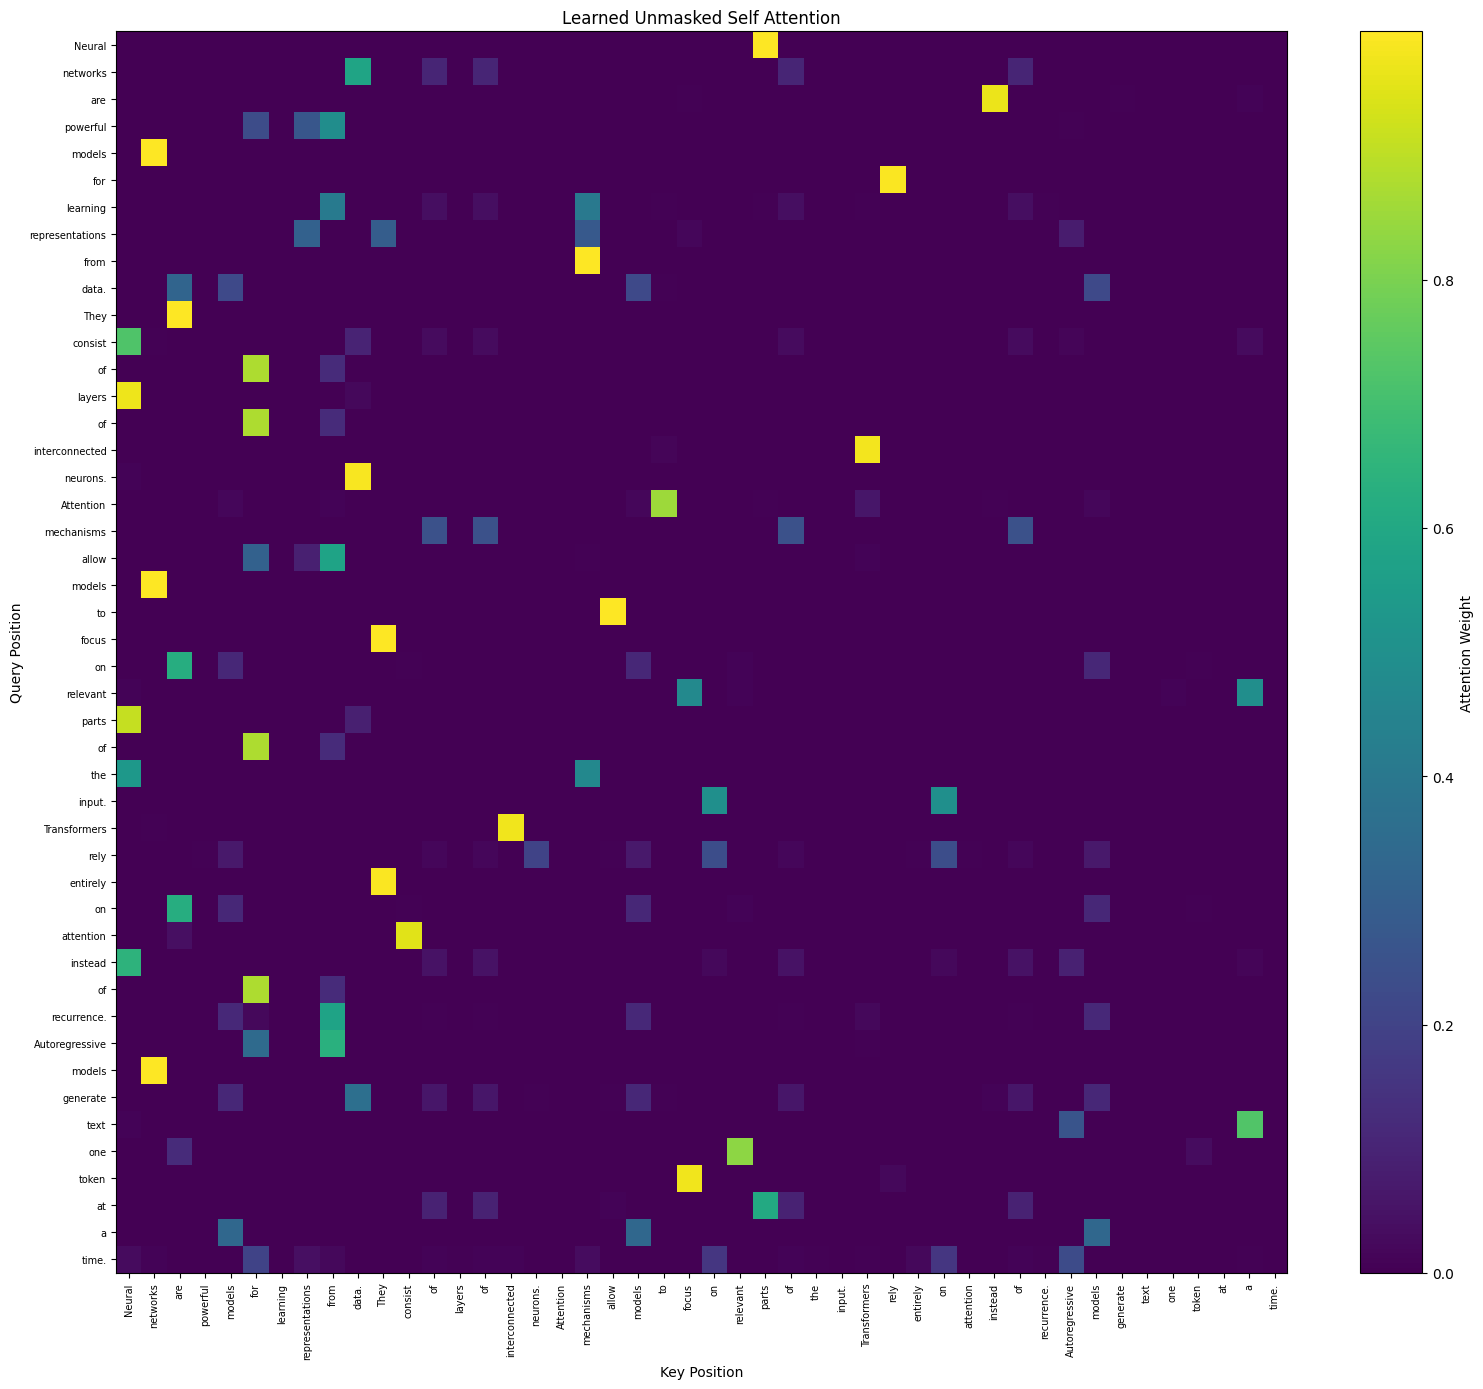

In [ ]:
def plot_attention_heatmap(attention, labels, title, filename):
    n = len(labels)
    plt.figure(figsize=(16, 14))
    image = plt.imshow(attention, aspect="auto", interpolation="nearest")
    plt.colorbar(image, label="Attention Weight")
    plt.xticks(range(n), labels, rotation=90, fontsize=7)
    plt.yticks(range(n), labels, fontsize=7)
    plt.xlabel("Key Position")
    plt.ylabel("Query Position")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

plot_attention_heatmap(
    unmasked_attention_np,
    tokens,
    "Learned Unmasked Self Attention",
    "figures/unmasked_attention_heatmap.png"
)

### Unmasked Attention Result

The learned unmasked attention matrix has shape **46 by 46**, matching the 46 token positions in the dataset. Its row sums are numerically equal to 1, with a maximum floating point error of about \(2.38 \times 10^{-7}\).

The model began with a loss of **3.701041** and ended at **0.228414**, with a minimum observed loss of **0.227368**. The total attention placed on future positions is **13.463081**. This confirms that the unmasked model learned to use information to the right of the current token, which is allowed because no causal restriction is applied.


## Causal Masked Model

The second model is trained separately with a lower triangular causal mask. At position \(i\), it may attend only to position \(i\) and positions that came before it. Future scores are blocked before softmax.


In [ ]:
masked_model, masked_losses = train_model(causal=True, seed=SEED)

Epoch   1/500 | Loss: 3.714020
Epoch 100/500 | Loss: 0.246548
Epoch 200/500 | Loss: 0.216079
Epoch 300/500 | Loss: 0.215781
Epoch 400/500 | Loss: 0.215750
Epoch 500/500 | Loss: 0.217287


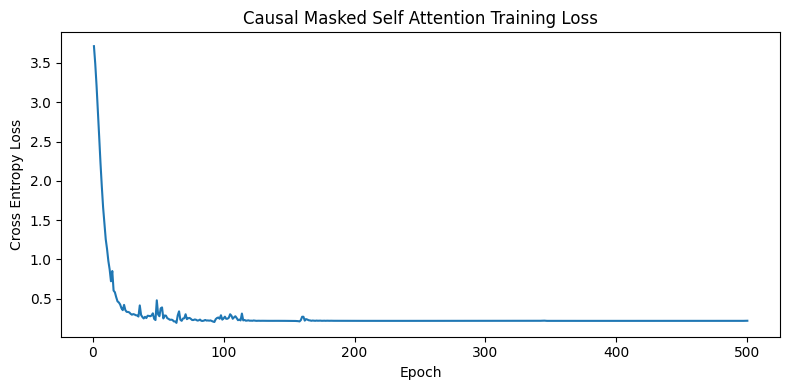

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(masked_losses) + 1), masked_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Causal Masked Self Attention Training Loss")
plt.tight_layout()
plt.savefig("figures/masked_training_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
masked_model.eval()

with torch.no_grad():
    _, masked_attention = masked_model(full_ids, return_attention=True)

masked_attention_np = masked_attention.cpu().numpy()
print("Attention matrix shape:", masked_attention_np.shape)
print("Maximum row sum error:", np.abs(masked_attention_np.sum(axis=1) - 1.0).max())

Attention matrix shape: (46, 46)
Maximum row sum error: 2.3841858e-07


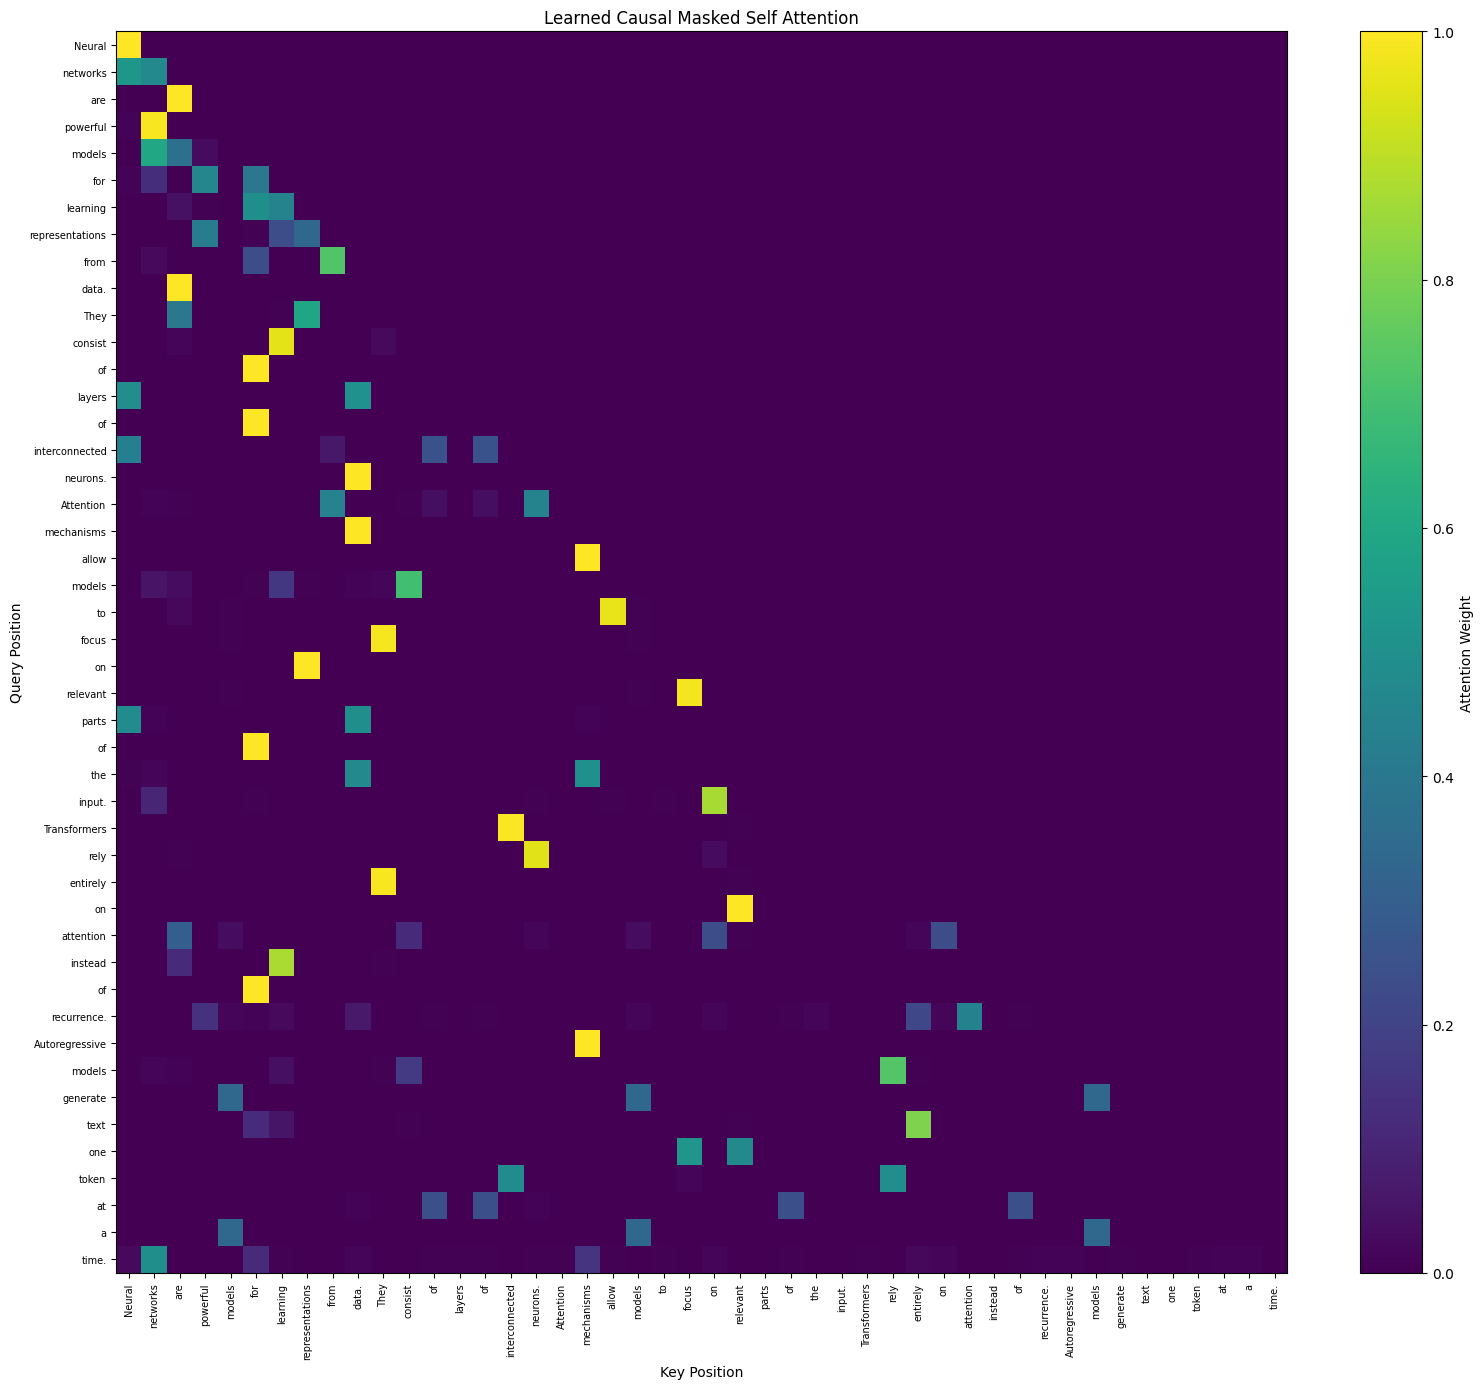

In [ ]:
plot_attention_heatmap(
    masked_attention_np,
    tokens,
    "Learned Causal Masked Self Attention",
    "figures/masked_attention_heatmap.png"
)

## Causal Mask Verification

A heatmap makes the masking pattern visible, but I also check it numerically. I select every entry above the main diagonal and measure both the largest future attention value and the sum of all future attention values.


In [ ]:
future_positions = np.triu(
    np.ones_like(masked_attention_np, dtype=bool),
    k=1
)

max_future_attention = float(np.max(masked_attention_np[future_positions]))
future_attention_sum = float(np.sum(masked_attention_np[future_positions]))

print("Maximum attention assigned to a future position:", max_future_attention)
print("Total attention assigned to future positions:", future_attention_sum)

assert np.allclose(masked_attention_np[future_positions], 0.0, atol=1e-7)
print("Causal mask verification passed.")

Maximum attention assigned to a future position: 0.0
Total attention assigned to future positions: 0.0
Causal mask verification passed.


### Mask Verification Result

The causal attention matrix has shape **46 by 46**. The maximum row sum error is about \(2.38 \times 10^{-7}\), confirming that each attention row remains properly normalized after masking.

The maximum attention assigned to any future position is **0.0**, and the sum of all future attention is also **0.0**. The numerical assertion passes, so the causal mask is doing exactly what it should. The upper triangular region of the attention matrix is therefore completely zero.

The masked model began with a loss of **3.714020** and ended at **0.217287**, with a minimum observed loss of **0.190088**.


# Model Comparison

The table below compares the two training runs using their initial loss, final loss, minimum observed loss, and total attention assigned to future positions.


In [ ]:
unmasked_future_sum = float(
    np.sum(
        unmasked_attention_np[
            np.triu(np.ones_like(unmasked_attention_np, dtype=bool), k=1)
        ]
    )
)

comparison_metrics = pd.DataFrame([
    {
        "Model": "Unmasked",
        "Initial loss": unmasked_losses[0],
        "Final loss": unmasked_losses[-1],
        "Minimum loss": min(unmasked_losses),
        "Future attention sum": unmasked_future_sum
    },
    {
        "Model": "Causal Masked",
        "Initial loss": masked_losses[0],
        "Final loss": masked_losses[-1],
        "Minimum loss": min(masked_losses),
        "Future attention sum": future_attention_sum
    }
])

comparison_metrics

,Model,Initial loss,Final loss,Minimum loss,Future attention sum
0,Unmasked,3.701041,0.228414,0.227368,13.463081
1,Causal Masked,3.714020,0.217287,0.190088,0.000000


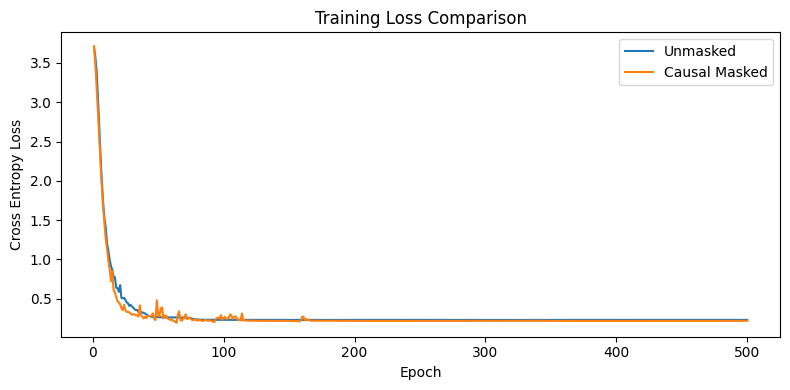

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(unmasked_losses) + 1), unmasked_losses, label="Unmasked")
plt.plot(range(1, len(masked_losses) + 1), masked_losses, label="Causal Masked")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/training_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Final Findings

Both models were trained for **500 epochs** using the same next token objective, seed, embedding size, attention dimension, optimizer, and learning rate. The unmasked model reduced its loss from **3.701041** to **0.228414**, while the causal masked model reduced its loss from **3.714020** to **0.217287**. Their minimum observed losses were **0.227368** and **0.190088**, respectively. The small loss difference on this single short dataset should not be interpreted as evidence that one architecture is generally better.

The main result is the learned attention pattern. The unmasked model assigned a total of **13.463081** attention weight to future positions. In contrast, the causal model assigned a maximum future attention value of **0.0** and a total future attention sum of **0.0**. This verifies that applying the lower triangular mask before softmax prevents every token from attending to later positions.

The heatmaps therefore demonstrate the intended distinction clearly. Unmasked self attention can use information from either side of a token, while causal self attention preserves the autoregressive constraint required for next token generation.


# Save Results

The final cells save the prompt outputs, attention metrics, figures, and a short run log so the numerical results used in the report can be reproduced from the executed notebook.


In [ ]:
comparison_metrics.to_csv("attention_metrics.csv", index=False)

with open("RUN_LOG.txt", "w", encoding="utf-8") as f:
    f.write("DATA 266 Homework 3 Run Summary\n")
    f.write(f"SID4: {SID4}\n")
    f.write(f"SEED: {SEED}\n")
    f.write(f"Device: {device}\n")
    f.write(f"Prompt calls completed: {len(prompt_results)}\n")
    f.write(f"Unmasked final loss: {unmasked_losses[-1]:.8f}\n")
    f.write(f"Masked final loss: {masked_losses[-1]:.8f}\n")
    f.write(f"Masked future attention sum: {future_attention_sum:.8f}\n")
    f.write("Causal mask verification: PASSED\n")

print("Results and figures saved.")

Results and figures saved.
